In [1]:

import cv2
from skimage.graph import route_through_array
from scipy.ndimage import distance_transform_edt
from data_utils import index_segmentations_df, export_calculated_masks
from plotting_utils import show_row_visuals, show_mask_outline
from crf import add_calculated_mask_column

Read annotation data

In [2]:
df = index_segmentations_df(
    r"C:\Users\chris\Desktop\University\Thesis\AnnotationsData\Segmentations"
)

# Only include the whole cell annotation for now, later we can do a custom soma segmentation
df = df[df['class'] == 'MG_whole']
print(len(df), "annotation pairs found")
df.head()

print(df.columns)



df = add_calculated_mask_column(df)



1009 annotation pairs found
Index(['scan', 'class', 'image_path', 'mask_path'], dtype='object')


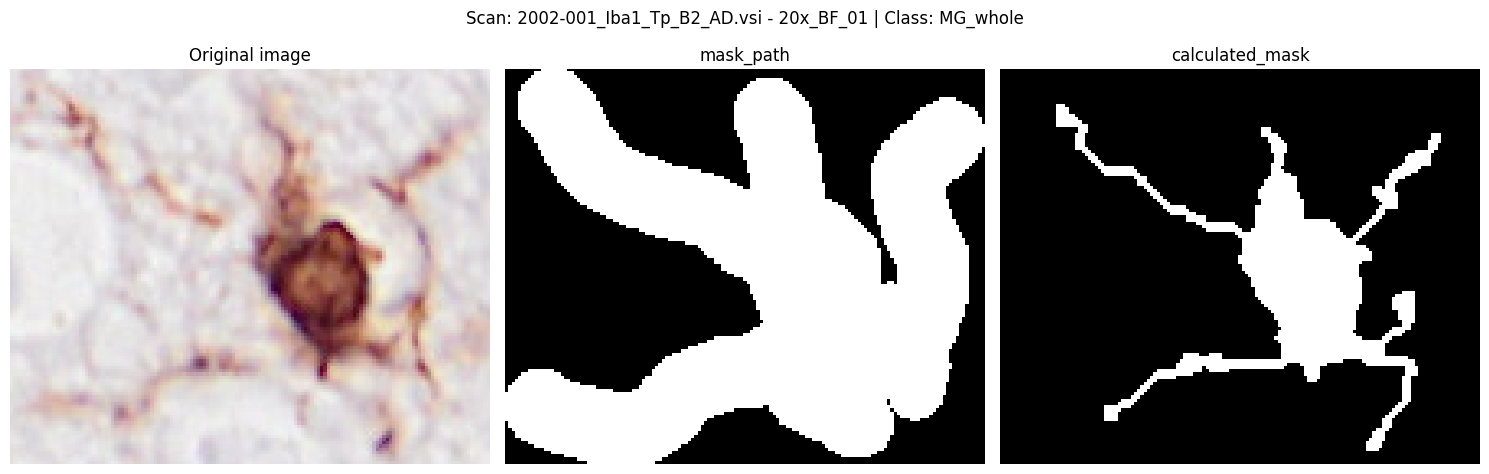

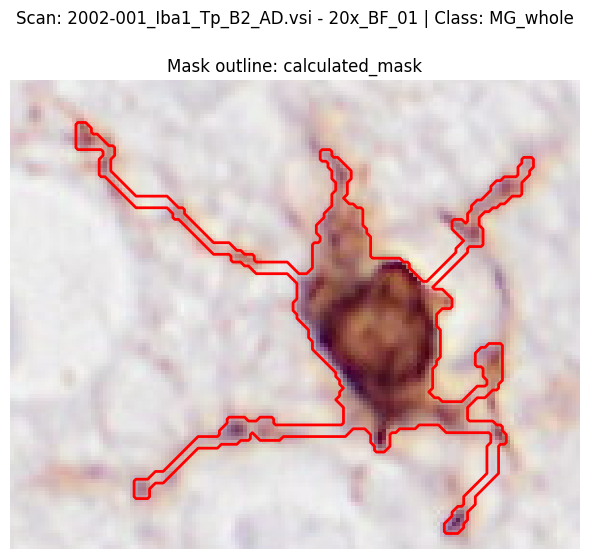

In [4]:
show_row_visuals(df, 19, columns = ["mask_path", 'calculated_mask'])
show_mask_outline(df, 19, mask_col = 'calculated_mask')

# for i in range(250, 350): 
#     print(f'current index if {i}')
#     show_row_visuals(df, i, columns = ["mask_path", 'calculated_mask'])
#     show_mask_outline(df, i, mask_col = 'calculated_mask')

# current ones seem to be a bit short / don't do well when it is too light

# blue indexes 
# 165

# Bad indexes 
# 16, 19

# Nice examples
# 27, 34, 35, 50, 51

In [ ]:
# Bad 
# 0, 19, 42, 44, 60, 82, 176, 204, 205, 261, 285, 
# - lots of these are very light colour


# Medium 
# 3,13, 16, 18, 21, 31, 38, 39, 45, 47, 48, 49, 56, 64, 73, 80, 91, 93, 97, 101, 105, 109, 110, 112, 116, 133, 135, 137, 138, 142, 144, 146, 155, 157, 160, 161, 162, 165, 170, 171, 172, 177, 182, 183, 184, 187, 188, 193, 196, 197, 198, 199, 200, 208, 209, 210, 216, 218, 219, 226, 228, 231, 234, 235, 238, 239, 242, 245, 249, 250, 259, 262, 265, 266, 268, 269, 271, 272, 274, 275, 276, 278, 281, 284, 286, 287,  288, 289, 293, 294, 296, 297, 299, 303, 304, 305, 308, 309, 310, 312, 315, 318, 319, 320, 323, 325, 326, 327, 328, 329, 330, 331, 333, 334, 336, 337, 339, 341, 343, 344, 345, 347, 348, 349, 

# Bad quality
# 4, 15, 191, 247

In [5]:
dir = r"C:\Users\chris\Desktop\University\Thesis\AnnotationsData"
export_calculated_masks(df, dir, mask_column='calculated_mask')